# Conformation count (water vs hexane) → PAMPA permeability

**Hypothesis (chameleonic mechanism).** A passively permeable cyclic peptide should accept *many* conformations in water (entropy-rich, polar groups exposed) but collapse to *few* in hexane (self-shielded, H-bond satisfied internally). So we predict:

- `n_clusters_water` ↑ correlates with higher permeability (PAMPA log Pe closer to −4)
- `n_clusters_hexane` ↓ correlates with higher permeability
- The ratio / difference `Δ = n_W − n_H` is the cleanest chameleonic score

**Data source.** Each peptide trajectory (100 frames in water, 100 in hexane) was clustered by GROMACS gromos with **RMSD cutoff 0.1 nm**. The number of clusters is the `Found N clusters` line in `*/Logs/*.log`. We parse all 5160 × 2 logs and merge with CycPeptMPDB-4D metadata.

**Caveat.** `n_clusters` is bounded by frame count (100) and depends on the cutoff. It's a *coarse* diversity index — finer alternatives (per-frame RMSD spread, entropy of cluster sizes) are computed too.

In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_style('whitegrid')

ROOT = '/ssd0/sohyun/cyclic_peptide/cyclic_peptide_permeability'
WATER_LOGS  = f'{ROOT}/CycPeptMPDB-4D/Water/Logs'
HEXANE_LOGS = f'{ROOT}/CycPeptMPDB-4D/Hexane/Logs'
META_CSV    = f'{ROOT}/data/CycPeptMPDB-4D.csv'

## 1. Parse all logs → conformation count

In [2]:
ID_RE     = re.compile(r'.+?_(\d+)_(H2O|Hexane)\.log$')
FOUND_RE  = re.compile(r'Found\s+(\d+)\s+clusters')
AVGRMSD_RE= re.compile(r'Average RMSD is\s+([\d.eE+-]+)')
RANGE_RE  = re.compile(r'RMSD ranges from\s+([\d.eE+-]+)\s+to\s+([\d.eE+-]+)')

def parse_log(path):
    n_clust = None; avg = None; lo = None; hi = None
    sizes = []
    with open(path) as f:
        for line in f:
            if (m := FOUND_RE.search(line)):    n_clust = int(m.group(1))
            elif (m := AVGRMSD_RE.search(line)): avg     = float(m.group(1))
            elif (m := RANGE_RE.search(line)):   lo, hi  = float(m.group(1)), float(m.group(2))
            else:
                # cluster table row:  '  1 |  12  0.102 | ...'
                m2 = re.match(r'\s*(\d+)\s*\|\s*(\d+)\s', line)
                if m2: sizes.append(int(m2.group(2)))
    return n_clust, avg, lo, hi, sizes

def parse_dir(dirpath, tag):
    rows = []
    for fn in os.listdir(dirpath):
        m = ID_RE.match(fn)
        if not m: continue
        pid = int(m.group(1))
        n, avg, lo, hi, sizes = parse_log(os.path.join(dirpath, fn))
        # Shannon entropy over cluster occupancies (informational diversity)
        H = np.nan
        if sizes:
            p = np.array(sizes, dtype=float); p = p / p.sum()
            H = float(-(p * np.log(p)).sum())
        rows.append({
            'CycPeptMPDB_ID': pid,
            f'n_clusters_{tag}': n,
            f'avgRMSD_nm_{tag}': avg,
            f'rmsd_min_nm_{tag}': lo,
            f'rmsd_max_nm_{tag}': hi,
            f'rmsd_range_nm_{tag}': (hi - lo) if (hi is not None and lo is not None) else np.nan,
            f'cluster_entropy_{tag}': H,
            f'top_cluster_pop_{tag}': sizes[0] if sizes else np.nan,
        })
    return pd.DataFrame(rows)

W = parse_dir(WATER_LOGS, 'water')
H = parse_dir(HEXANE_LOGS, 'hexane')
print('water rows:', len(W), '  hexane rows:', len(H))
W.head(3)

water rows: 5160   hexane rows: 5160


,CycPeptMPDB_ID,n_clusters_water,avgRMSD_nm_water,rmsd_min_nm_water,rmsd_max_nm_water,rmsd_range_nm_water,cluster_entropy_water,top_cluster_pop_water
0,4691,32,0.150369,0.041814,0.287483,0.245669,2.499018,39
1,1757,17,0.123555,0.051065,0.223082,0.172017,1.925493,44
2,1167,11,0.115805,0.037079,0.260915,0.223836,1.257125,68


In [3]:
meta = pd.read_csv(META_CSV)
df = meta.merge(W, on='CycPeptMPDB_ID').merge(H, on='CycPeptMPDB_ID')
df['delta_n_clusters'] = df['n_clusters_water'] - df['n_clusters_hexane']
df['ratio_n_clusters'] = df['n_clusters_water'] / df['n_clusters_hexane'].clip(lower=1)
df['delta_entropy']    = df['cluster_entropy_water'] - df['cluster_entropy_hexane']
df['delta_avgRMSD_nm'] = df['avgRMSD_nm_water'] - df['avgRMSD_nm_hexane']
print('Merged shape:', df.shape)
df[['CycPeptMPDB_ID','PAMPA','Monomer_Length','n_clusters_water','n_clusters_hexane','delta_n_clusters','avgRMSD_nm_water','avgRMSD_nm_hexane']].head()

Merged shape: (5160, 37)


,CycPeptMPDB_ID,PAMPA,Monomer_Length,n_clusters_water,n_clusters_hexane,delta_n_clusters,avgRMSD_nm_water,avgRMSD_nm_hexane
0,7067,-5.10,10,25,29,-4,0.134916,0.147242
1,7066,-5.40,10,13,17,-4,0.127582,0.120995
2,7065,-5.47,10,25,8,17,0.154597,0.109421
3,7064,-5.80,10,24,35,-11,0.153297,0.136283
4,7063,-5.29,10,23,14,9,0.142324,0.123187


## 2. Sanity check — distributions

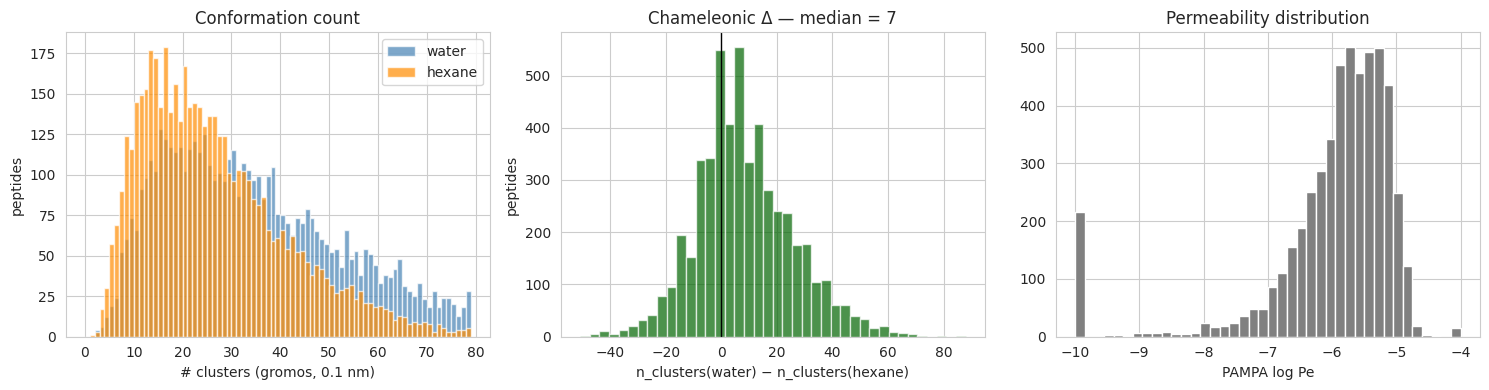

n_clusters_water  — median 31, IQR 19-46
n_clusters_hexane — median 23, IQR 14-34
Peptides where n_W > n_H: 66.1%


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['n_clusters_water'],  bins=np.arange(0, 80), alpha=0.7, label='water',  color='steelblue')
axes[0].hist(df['n_clusters_hexane'], bins=np.arange(0, 80), alpha=0.7, label='hexane', color='darkorange')
axes[0].set_xlabel('# clusters (gromos, 0.1 nm)'); axes[0].set_ylabel('peptides'); axes[0].set_title('Conformation count')
axes[0].legend()
axes[1].hist(df['delta_n_clusters'], bins=40, color='darkgreen', alpha=0.7)
axes[1].axvline(0, color='k', lw=1)
axes[1].set_xlabel('n_clusters(water) − n_clusters(hexane)'); axes[1].set_ylabel('peptides')
axes[1].set_title(f'Chameleonic Δ — median = {df["delta_n_clusters"].median():.0f}')
axes[2].hist(df['PAMPA'], bins=40, color='gray')
axes[2].set_xlabel('PAMPA log Pe'); axes[2].set_title('Permeability distribution')
plt.tight_layout(); plt.show()

print('n_clusters_water  — median {0:.0f}, IQR {1:.0f}-{2:.0f}'.format(*df['n_clusters_water'].quantile([0.5, 0.25, 0.75]).values))
print('n_clusters_hexane — median {0:.0f}, IQR {1:.0f}-{2:.0f}'.format(*df['n_clusters_hexane'].quantile([0.5, 0.25, 0.75]).values))
print(f'Peptides where n_W > n_H: {(df["delta_n_clusters"] > 0).mean()*100:.1f}%')

## 3. Global correlation: conformation count vs PAMPA

We use **Spearman** (rank, robust to monotone non-linearity) and report Pearson alongside. n_clusters is integer-valued so Spearman is the right primary statistic.

In [5]:
def corr(x, y, name):
    mask = x.notna() & y.notna()
    sp = stats.spearmanr(x[mask], y[mask])
    pe = stats.pearsonr (x[mask], y[mask])
    return {'feature': name, 'n': int(mask.sum()),
            'spearman_r': sp.statistic, 'spearman_p': sp.pvalue,
            'pearson_r':  pe.statistic, 'pearson_p':  pe.pvalue}

features = ['n_clusters_water','n_clusters_hexane','delta_n_clusters','ratio_n_clusters',
            'cluster_entropy_water','cluster_entropy_hexane','delta_entropy',
            'avgRMSD_nm_water','avgRMSD_nm_hexane','delta_avgRMSD_nm']
tbl = pd.DataFrame([corr(df[f], df['PAMPA'], f) for f in features])
tbl = tbl.sort_values('spearman_r', key=lambda s: s.abs(), ascending=False)
tbl.style.format({'spearman_r':'{:+.3f}', 'spearman_p':'{:.1e}', 'pearson_r':'{:+.3f}', 'pearson_p':'{:.1e}'})

,feature,n,spearman_r,spearman_p,pearson_r,pearson_p
7,avgRMSD_nm_water,5160,-0.147,2.5e-26,-0.088,2.1e-10
0,n_clusters_water,5160,-0.127,5.9e-20,-0.062,8.7e-06
4,cluster_entropy_water,5160,-0.114,2.0e-16,-0.052,1.7e-04
2,delta_n_clusters,5160,-0.110,1.8e-15,-0.059,2.1e-05
9,delta_avgRMSD_nm,5160,-0.101,3.6e-13,-0.064,4.2e-06
3,ratio_n_clusters,5160,-0.095,7.4e-12,-0.046,9.5e-04
6,delta_entropy,5160,-0.094,1.6e-11,-0.054,1.1e-04
8,avgRMSD_nm_hexane,5160,-0.047,7.6e-04,-0.016,2.4e-01
1,n_clusters_hexane,5160,-0.038,7.1e-03,-0.008,5.5e-01
5,cluster_entropy_hexane,5160,-0.024,8.0e-02,+0.004,7.7e-01


/tmp/ipykernel_512317/2807859824.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = sub.groupby(bins)['PAMPA'].median()
/tmp/ipykernel_512317/2807859824.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = sub.groupby(bins)[col].mean()
/tmp/ipykernel_512317/2807859824.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = sub.groupby(bins)['PAMPA'].median()
/tmp/ipykernel_512317/2807859824.py:10: FutureWa

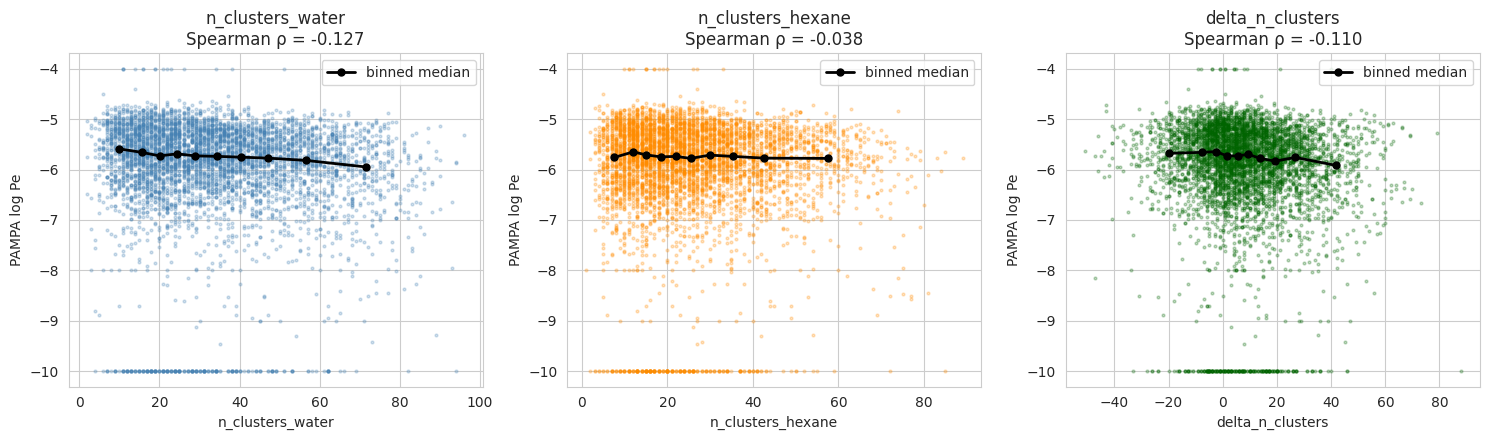

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, color in zip(axes,
                          ['n_clusters_water','n_clusters_hexane','delta_n_clusters'],
                          ['steelblue','darkorange','darkgreen']):
    sub = df[[col,'PAMPA']].dropna()
    ax.scatter(sub[col], sub['PAMPA'], s=4, alpha=0.25, color=color)
    # binned median
    bins = pd.qcut(sub[col], 10, duplicates='drop')
    g = sub.groupby(bins)['PAMPA'].median()
    centers = sub.groupby(bins)[col].mean()
    ax.plot(centers, g, 'k-o', ms=5, lw=2, label='binned median')
    rho = stats.spearmanr(sub[col], sub['PAMPA']).statistic
    ax.set_xlabel(col); ax.set_ylabel('PAMPA log Pe')
    ax.set_title(f'{col}\nSpearman ρ = {rho:+.3f}')
    ax.legend()
plt.tight_layout(); plt.show()

## 4. Stratified by peptide length

Cyclic peptide flexibility grows superlinearly with ring size, so a chameleonic signal that exists for big rings may be invisible for small ones (or vice versa). We re-run the correlation within each `Monomer_Length` bucket.

In [7]:
print('Length distribution:')
print(df['Monomer_Length'].value_counts().sort_index())

Length distribution:
Monomer_Length
6     1845
7     1919
10    1396
Name: count, dtype: int64


In [8]:
rows = []
for L, sub in df.groupby('Monomer_Length'):
    if len(sub) < 30: continue
    for f in ['n_clusters_water','n_clusters_hexane','delta_n_clusters','avgRMSD_nm_water','avgRMSD_nm_hexane']:
        r = stats.spearmanr(sub[f], sub['PAMPA'], nan_policy='omit')
        rows.append({'length': L, 'n': len(sub), 'feature': f, 'spearman_r': r.statistic, 'p': r.pvalue})
perlen = pd.DataFrame(rows)
pivot = perlen.pivot(index='length', columns='feature', values='spearman_r')
pivot_n = perlen.pivot(index='length', columns='feature', values='p')
print('Spearman ρ per length (rows: ring size, cols: feature)')
pivot.style.background_gradient(cmap='RdBu_r', vmin=-0.5, vmax=0.5, axis=None).format('{:+.3f}')

Spearman ρ per length (rows: ring size, cols: feature)


feature,avgRMSD_nm_hexane,avgRMSD_nm_water,delta_n_clusters,n_clusters_hexane,n_clusters_water
length,,,,,
6,-0.086,-0.208,-0.155,-0.043,-0.169
7,-0.030,-0.166,-0.113,-0.040,-0.147
10,-0.072,-0.107,-0.051,-0.084,-0.107


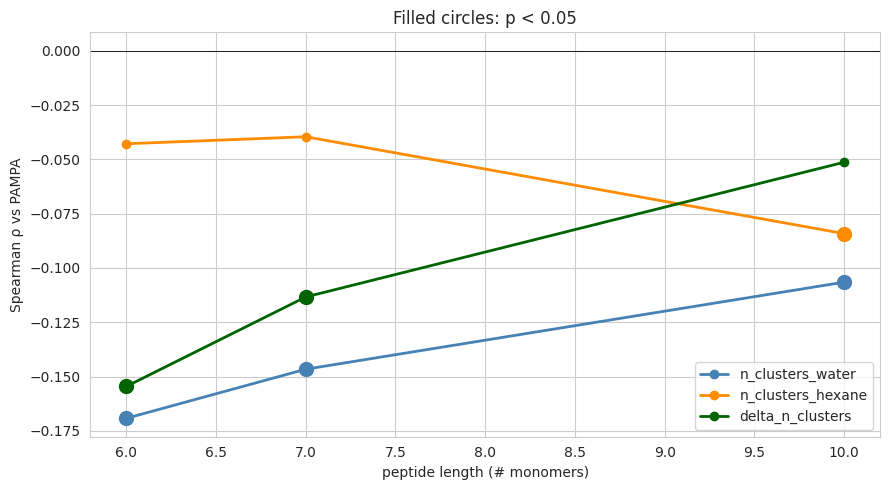

In [9]:
# Plot ρ-vs-length to see where the chameleonic signal is strong
fig, ax = plt.subplots(figsize=(9, 5))
for f, col in zip(['n_clusters_water','n_clusters_hexane','delta_n_clusters'],
                  ['steelblue','darkorange','darkgreen']):
    s = perlen[perlen.feature == f].sort_values('length')
    ax.plot(s['length'], s['spearman_r'], 'o-', color=col, label=f, lw=2)
    # annotate p-value: bold filled if p<0.05
    for _, r in s.iterrows():
        if r['p'] < 0.05:
            ax.plot(r['length'], r['spearman_r'], 'o', color=col, ms=10, mfc=col)
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('peptide length (# monomers)')
ax.set_ylabel('Spearman ρ vs PAMPA')
ax.set_title('Filled circles: p < 0.05')
ax.legend(); plt.tight_layout(); plt.show()

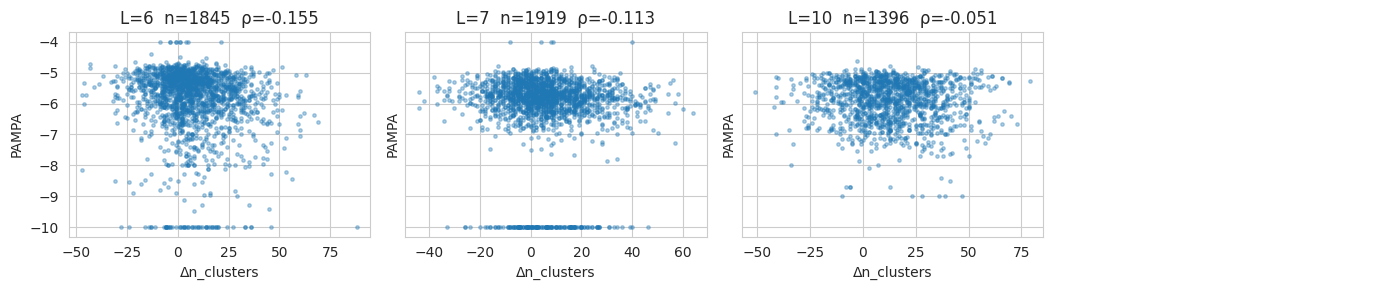

In [10]:
# Per-length scatter for delta_n_clusters — does its meaning shift?
lengths = sorted(df['Monomer_Length'].unique())
lengths_keep = [L for L in lengths if (df['Monomer_Length']==L).sum() >= 30]
ncol = 4; nrow = int(np.ceil(len(lengths_keep)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*3.5, nrow*3), sharey=True)
axes = np.atleast_2d(axes).ravel()
for i, L in enumerate(lengths_keep):
    sub = df[df['Monomer_Length']==L][['delta_n_clusters','PAMPA']].dropna()
    ax = axes[i]
    ax.scatter(sub['delta_n_clusters'], sub['PAMPA'], s=6, alpha=0.35)
    rho = stats.spearmanr(sub['delta_n_clusters'], sub['PAMPA']).statistic
    ax.set_title(f'L={L}  n={len(sub)}  ρ={rho:+.3f}')
    ax.set_xlabel('Δn_clusters'); ax.set_ylabel('PAMPA')
for j in range(len(lengths_keep), len(axes)): axes[j].axis('off')
plt.tight_layout(); plt.show()

## 5. Does the chameleonic Δ explain permeability *beyond* known descriptors?

PSA, NPSA and Rg-proxy are the textbook predictors of PAMPA. Partial Spearman tells us whether `delta_n_clusters` adds anything once we control for `Hexane_3D_PSA` and `Monomer_Length`.

In [11]:
from numpy.linalg import lstsq

def partial_spearman(df, x, y, controls):
    """Spearman of residuals after rank-regressing controls out of x and y."""
    sub = df[[x, y] + controls].dropna()
    Xc  = np.column_stack([np.ones(len(sub))] + [sub[c].rank().values for c in controls])
    def resid(v):
        b, *_ = lstsq(Xc, v.rank().values, rcond=None)
        return v.rank().values - Xc @ b
    rx, ry = resid(sub[x]), resid(sub[y])
    r = stats.spearmanr(rx, ry)
    return r.statistic, r.pvalue, len(sub)

rows = []
controls_list = [
    ['Monomer_Length'],
    ['Monomer_Length','Hexane_3D_PSA'],
    ['Monomer_Length','Hexane_3D_PSA','Hexane_3D_NPSA'],
]
for f in ['n_clusters_water','n_clusters_hexane','delta_n_clusters','avgRMSD_nm_water','delta_avgRMSD_nm']:
    for C in controls_list:
        r, p, n = partial_spearman(df, f, 'PAMPA', C)
        rows.append({'feature': f, 'controls': '+'.join(C), 'n': n, 'partial_rho': r, 'p': p})
partial_tbl = pd.DataFrame(rows)
partial_tbl.style.format({'partial_rho':'{:+.3f}','p':'{:.1e}'})

,feature,controls,n,partial_rho,p
0,n_clusters_water,Monomer_Length,5160,-0.112,5.7e-16
1,n_clusters_water,Monomer_Length+Hexane_3D_PSA,5160,-0.075,6.9e-08
2,n_clusters_water,Monomer_Length+Hexane_3D_PSA+Hexane_3D_NPSA,5160,-0.155,5.7e-29
3,n_clusters_hexane,Monomer_Length,5160,-0.036,9.0e-03
4,n_clusters_hexane,Monomer_Length+Hexane_3D_PSA,5160,+0.011,4.4e-01
5,n_clusters_hexane,Monomer_Length+Hexane_3D_PSA+Hexane_3D_NPSA,5160,-0.076,4.6e-08
6,delta_n_clusters,Monomer_Length,5160,-0.099,8.8e-13
7,delta_n_clusters,Monomer_Length+Hexane_3D_PSA,5160,-0.098,1.7e-12
8,delta_n_clusters,Monomer_Length+Hexane_3D_PSA+Hexane_3D_NPSA,5160,-0.102,1.9e-13
9,avgRMSD_nm_water,Monomer_Length,5160,-0.141,1.7e-24


## 6. Summary of findings

Auto-generated below from the computed tables (re-run after data changes).

In [12]:
best_global = tbl.iloc[0]
best_perlen = perlen.iloc[perlen['spearman_r'].abs().idxmax()]
print(f"Strongest global predictor of PAMPA:  {best_global['feature']}  "
      f"(Spearman ρ = {best_global['spearman_r']:+.3f}, p = {best_global['spearman_p']:.1e}, n = {best_global['n']})")
print(f"Strongest per-length signal:           L = {int(best_perlen['length'])}, "
      f"{best_perlen['feature']}, ρ = {best_perlen['spearman_r']:+.3f} (n = {int(best_perlen['n'])})")
print()
print('Per-length ρ for delta_n_clusters:')
print(perlen[perlen.feature=='delta_n_clusters'].sort_values('length')[['length','n','spearman_r','p']].to_string(index=False))

Strongest global predictor of PAMPA:  avgRMSD_nm_water  (Spearman ρ = -0.147, p = 2.5e-26, n = 5160)
Strongest per-length signal:           L = 6, avgRMSD_nm_water, ρ = -0.208 (n = 1845)

Per-length ρ for delta_n_clusters:
 length    n  spearman_r            p
      6 1845   -0.154562 2.478622e-11
      7 1919   -0.113374 6.379785e-07
     10 1396   -0.051351 5.508887e-02
